<a href="https://colab.research.google.com/github/vlp19/NBA-Lottery-How-to-Fix-the-Tanking-Epidemic/blob/main/Tanking_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import time
import psycopg2
import psycopg2.extras as extras
!pip install nba_api
from nba_api.stats.endpoints import leaguedashteamstats
from nba_api.stats.static import teams

# conn_params = {
#     "host": "_________",
#     "database": "_________________",
#     "user": "__________",
#     "password": "_____________"
# }

In [ ]:
# def populate_teams_table():
#     nba_teams = teams.get_teams()
#     tuples = [(t['id'], t['abbreviation'], t['nickname']) for t in nba_teams]

#     query = """
#     INSERT INTO teams (team_id, abbreviation, nickname)
#     VALUES %s
#     ON CONFLICT (team_id) DO NOTHING;
#     """

#     conn = psycopg2.connect(**conn_params)
#     cursor = conn.cursor()
#     try:
#         extras.execute_values(cursor, query, tuples)
#         conn.commit()
#         print(f"Successfully synced {len(tuples)} teams to the metadata table.")
#     except Exception as e:
#         print(f"Error populating teams: {e}")
#         conn.rollback()
#     finally:
#         cursor.close()
#         conn.close()

In [ ]:
  # def execute_upsert(df, table):
  #   tuples = [tuple(x) for x in df[['team_id', 'season_year', 'wins', 'losses',
  #                                  'points_for', 'points_against',
  #                                  'playoff_games_won', 'championship_won']].values]

  #   query = f"""
  #   INSERT INTO {table} (team_id, season_year, wins, losses, points_for, points_against, playoff_games_won, championship_won)
  #   VALUES %s
  #   ON CONFLICT (team_id, season_year)
  #   DO UPDATE SET
  #       wins = EXCLUDED.wins,
  #       losses = EXCLUDED.losses,
  #       points_for = EXCLUDED.points_for,
  #       points_against = EXCLUDED.points_against,
  #       playoff_games_won = EXCLUDED.playoff_games_won,
  #       championship_won = EXCLUDED.championship_won;
  #   """

  #   conn = psycopg2.connect(**conn_params)
  #   cursor = conn.cursor()
  #   try:
  #       extras.execute_values(cursor, query, tuples)
  #       conn.commit()
  #       print(f"Successfully upserted {len(df)} rows into {table}.")
  #   except (Exception, psycopg2.DatabaseError) as error:
  #       print(f"Error: {error}")
  #       conn.rollback()
  #   finally:
  #       cursor.close()
  #       conn.close()

In [ ]:
# def run_full_import():
#     populate_teams_table()

#     years = [2021, 2022, 2023, 2024, 2025]

#     for year in years:
#         season_str = f"{year}-{str(year+1)[2:]}"
#         print(f"--- Fetching {season_str} via LeagueDashTeamStats ---")

#         try:
#             stats = leaguedashteamstats.LeagueDashTeamStats(
#                 season=season_str,
#                 season_type_all_star='Regular Season'
#             )
#             df = stats.get_data_frames()[0]

#             df_mapped = pd.DataFrame()
#             df_mapped['team_id'] = df['TEAM_ID'].astype(int)
#             df_mapped['wins'] = df['W'].astype(int)
#             df_mapped['losses'] = df['L'].astype(int)
#             df_mapped['points_for'] = df['PTS'].astype(int)
#             df_mapped['points_against'] = (df['PTS'] - df['PLUS_MINUS']).astype(int)

#             df_mapped['season_year'] = year
#             df_mapped['playoff_games_won'] = 0
#             df_mapped['championship_won'] = False

#             execute_upsert(df_mapped, 'team_seasons')

#             time.sleep(1.5)

#         except Exception as e:
#             print(f"Failed to process {season_str}: {e}")

# run_full_import()

In [ ]:
# nba_teams = teams.get_teams()

# team_list = [{"name": team['full_name'], "id": team['id'], "abbreviation": team['abbreviation']} for team in nba_teams]

# for team in team_list:
#     print(f"Team: {team['name']}, Abbreviation: {team['abbreviation']}, ID: {team['id']}")

In [ ]:
# playoff_data = {
#     2021: {
#         1610612749: (16, True),   # Bucks (Champions)
#         1610612756: (14, False),  # Suns
#         1610612746: (10, False),  # Clippers
#         1610612737: (10, False),  # Hawks
#         1610612755: (7, False),   # 76ers
#         1610612751: (7, False),   # Nets
#         1610612762: (6, False),   # Jazz
#         1610612743: (4, False),   # Nuggets
#         1610612742: (3, False),   # Mavericks
#         1610612757: (2, False),   # Trail Blazers
#         1610612747: (2, False),   # Lakers
#         1610612752: (1, False),   # Knicks
#         1610612738: (1, False),   # Celtics
#         1610612763: (1, False),   # Grizzlies
#         1610612764: (1, False),   # Wizards
#         1610612748: (0, False)    # Heat
#     },
#     2022: {
#         1610612744: (16, True),   # Warriors (Champions)
#         1610612738: (14, False),  # Celtics
#         1610612748: (11, False),  # Heat
#         1610612742: (9, False),   # Mavericks
#         1610612756: (7, False),   # Suns
#         1610612763: (6, False),   # Grizzlies
#         1610612755: (6, False),   # 76ers
#         1610612749: (7, False),   # Bucks
#         1610612740: (2, False),   # Pelicans
#         1610612750: (2, False),   # Timberwolves
#         1610612762: (2, False),   # Jazz
#         1610612753: (1, False),   # Magic
#         1610612743: (1, False),   # Nuggets
#         1610612737: (1, False),   # Hawks
#         1610612741: (1, False),   # Bulls
#         1610612751: (0, False)    # Nets
#     },
#     2023: {
#         1610612743: (16, True),   # Nuggets (Champions)
#         1610612748: (13, False),  # Heat
#         1610612738: (11, False),  # Celtics
#         1610612747: (8, False),   # Lakers
#         1610612755: (7, False),   # 76ers
#         1610612752: (6, False),   # Knicks
#         1610612756: (6, False),   # Suns
#         1610612744: (7, False),   # Warriors
#         1610612758: (3, False),   # Kings
#         1610612739: (1, False),   # Cavaliers
#         1610612763: (2, False),   # Grizzlies
#         1610612746: (1, False),   # Clippers
#         1610612737: (2, False),   # Hawks
#         1610612750: (1, False),   # Timberwolves
#         1610612749: (1, False),   # Bucks
#         1610612751: (0, False)    # Nets
#     },
#     2024: {
#         1610612738: (16, True),   # Celtics (Champions)
#         1610612742: (13, False),  # Mavericks
#         1610612750: (9, False),   # Timberwolves
#         1610612739: (7, False),   # Cavaliers
#         1610612743: (7, False),   # Nuggets
#         1610612752: (7, False),   # Knicks
#         1610612754: (8, False),   # Pacers
#         1610612760: (4, False),   # Thunder
#         1610612748: (1, False),   # Heat
#         1610612755: (2, False),   # 76ers
#         1610612749: (2, False),   # Bucks
#         1610612753: (3, False),   # Magic
#         1610612746: (2, False),   # Clippers
#         1610612747: (1, False),   # Lakers
#         1610612740: (0, False),   # Pelicans
#         1610612756: (0, False)    # Suns
#     },
#     2025: {
#         1610612760: (16, True),   # Thunder (Champions)
#         1610612738: (14, False),  # Celtics
#         1610612750: (10, False),  # Timberwolves
#         1610612754: (10, False),  # Pacers
#         1610612743: (7, False),   # Nuggets
#         1610612752: (6, False),   # Knicks
#         1610612739: (6, False),   # Cavaliers
#         1610612742: (5, False),   # Mavericks
#         1610612755: (3, False),   # 76ers
#         1610612749: (2, False),   # Bucks
#         1610612753: (2, False),   # Magic
#         1610612756: (2, False),   # Suns
#         1610612746: (1, False),   # Clippers
#         1610612747: (1, False),   # Lakers
#         1610612748: (0, False),   # Heat
#         1610612740: (0, False)    # Pelicans
#     }
# }

In [ ]:
# def update_playoff_stats(playoff_dict):
#     conn = psycopg2.connect(**conn_params)
#     cursor = conn.cursor()
#     try:
#         for year, teams in playoff_dict.items():
#             for team_id, (wins, champ) in teams.items():
#                 cursor.execute("""
#                     UPDATE team_seasons
#                     SET playoff_games_won = %s, championship_won = %s
#                     WHERE team_id = %s AND season_year = %s
#                 """, (wins, champ, team_id, year))
#         conn.commit()
#         print("Playoff stats updated successfully.")
#     except Exception as e:
#         print(f"Error: {e}")
#         conn.rollback()
#     finally:
#         cursor.close()
#         conn.close()

# update_playoff_stats(playoff_data)

# Creating a Nerual Network for NBA Tanking Prevention
### The NBA has a crucial issue with teams consistently tanking, or purposely losing games in the hopes for beneficial future treatment, when teams are missing key pieces or looking to stack draft picks
### The NBA has also recently instituted two mid-season tournaments, called the Emirates NBA Cup and the "play-in" tournament, which currently do not have much incentive to win other than a (probably more embarrassing than exhilarating) tournament trophy and player bonuses
### In order to remedy this issue, I've come up with a solution that is threefold:
- #### Build a neural network based on a model that measures characteristics of a tanking team and predicts tournament integrity
- #### Run monte carlo simulations which embed that neural network to model the probabilistic nature of the NBA draft lottery
- #### Analyze the results with payoff matrices

## **Initial Success Score**
### As a first step, we define a rough initial success score. This score is calculated based on win percentage, net rating, playoff wins, and championship wins, which were assigned weights of 0.3, 0.2, 0.4, and 0.1 respectively.
### Teams that performed better during a certain year (i.e. deep playoff run, positive win differential, championship winners, etc) generally received a higher success score for that year

In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import warnings
# warnings.filterwarnings("ignore", category=UserWarning, message=".*pandas only supports SQLAlchemy connectable.*")
# def view_success_trends():
#     conn = psycopg2.connect(**conn_params)
#     query = """
#     SELECT t.nickname, s.season_year,
#            (0.3 * (s.wins::float/82) + 0.4 * (s.playoff_games_won::float/16)) as score
#     FROM team_seasons s
#     JOIN teams t ON s.team_id = t.team_id
#     WHERE s.season_year >= 2021;
#     """
#     df = pd.read_sql(query, conn)
#     conn.close()

#     # Pivot for a Heatmap or Line Plot
#     pivot_df = df.pivot(index="nickname", columns="season_year", values="score")

#     plt.figure(figsize=(12, 8))
#     sns.heatmap(pivot_df, annot=True, cmap="YlGnBu", fmt=".3f")
#     plt.title("Team Success Scores (2021-2026)")
#     plt.show()

# view_success_trends()

## **Rolling 3-Year Averages**
- ### We take a team's previous 2 years of success scores along with the team's current success score and calculate rolling averages for each team per each year
- ### Since data only goes as far back as 2021, rolling averages for 2021 are simply the same as the success scores for 2021 and rolling averages for 2022 are the average of the score from 2021 and the score from 2022

In [ ]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# import psycopg2
# import warnings

# warnings.filterwarnings("ignore", category=UserWarning, module='pandas')

# def plot_rolling_success():
#     conn = psycopg2.connect(**conn_params)

#     query = """
#     SELECT
#         t.nickname,
#         s.season_year,
#         AVG((0.3 * (s.wins::float/82) + 0.4 * (s.playoff_games_won::float/16)))
#             OVER (PARTITION BY s.team_id ORDER BY s.season_year ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) as rolling_score
#     FROM team_seasons s
#     JOIN teams t ON s.team_id = t.team_id
#     WHERE s.season_year >= 2021;
#     """

#     df = pd.read_sql(query, conn)
#     conn.close()


#     pivot_df = df.pivot(index="nickname", columns="season_year", values="rolling_score")

#     plt.figure(figsize=(14, 10))
#     sns.heatmap(pivot_df, annot=True, cmap="YlGnBu", fmt=".3f")
#     plt.title("NBA Team 3-Year Rolling Success Index (2021-2026)")
#     plt.xlabel("Season (Ending Year)")
#     plt.ylabel("Team")
#     plt.show()

# plot_rolling_success()

## **Performance Anomaly Index**
### The performance anomaly index (PAI) is a concise measure of how a team has performed as compared to their historic counterparts
### If the PAI value for a team remains consistently high, then this is a sign of a historically strong team. If the PAI value remains low, then this is the sign of a historically weak team
### In general, we are looking to identify two things:
- #### If a team has a sudden fall into red after consistent years of light or deep blue
- #### If a team is continuously deep red and remains continuously deep red

In [ ]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# import psycopg2
# import warnings

# warnings.filterwarnings("ignore", category=UserWarning, module='pandas')

# def plot_anomaly_heatmap():
#     conn = psycopg2.connect(**conn_params)

#     query = """
#     WITH metrics AS (
#         SELECT
#             t.nickname,
#             s.season_year,
#             (0.3 * (s.wins::float/82) + 0.4 * (s.playoff_games_won::float/16)) as current_score,
#             AVG((0.3 * (s.wins::float/82) + 0.4 * (s.playoff_games_won::float/16)))
#                 OVER (PARTITION BY s.team_id ORDER BY s.season_year ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) as rolling_score
#         FROM team_seasons s
#         JOIN teams t ON s.team_id = t.team_id
#     )
#     SELECT nickname, season_year, (current_score - rolling_score) as anomaly_delta
#     FROM metrics
#     WHERE season_year >= 2023; -- Deltas only make sense once we have a rolling window established
#     """

#     df = pd.read_sql(query, conn)
#     conn.close()

#     pivot_df = df.pivot(index="nickname", columns="season_year", values="anomaly_delta")

#     plt.figure(figsize=(14, 10))
#     sns.heatmap(pivot_df, annot=True, cmap="RdBu", center=0, fmt=".3f")
#     plt.title("Performance Anomaly Index")
#     plt.xlabel("Season")
#     plt.ylabel("Team")
#     plt.show()

# plot_anomaly_heatmap()

## **Neural Network**
### The goal of the neural network is to separate the teams with legitimate roster struggles from teams that tank
### It will output a tanking probability value ($T_p$) between 0 and 1. Teams that have a tanking probability close to 0 are classified as not tanking. Teams that have a tanking probability close to 1 are classified as a tanking team.
### I will provide the anomaly index of thirty teams classified as 'tankers" and another thirty teams classified as "non-tankers" to train the network

In [ ]:
# import pandas as pd
# import time
# from nba_api.stats.static import teams
# from nba_api.stats.endpoints import teamyearbyyearstats
# import warnings

# warnings.filterwarnings("ignore", category=UserWarning, module='pandas')

# tanking_requests = [
#     {"team_id": 1610612745, "season": "1983-84", "description": "Houston Rockets"},
#     {"team_id": 1610612738, "season": "1996-97", "description": "Boston Celtics"},
#     {"team_id": 1610612763, "season": "2017-18", "description": "Memphis Grizzlies"},
#     {"team_id": 1610612739, "season": "2002-03", "description": "Cleveland Cavaliers"},
#     {"team_id": 1610612743, "season": "2002-03", "description": "Denver Nuggets"},
#     {"team_id": 1610612737, "season": "2003-04", "description": "Atlanta Hawks"},
#     {"team_id": 1610612742, "season": "1993-94", "description": "Dallas Mavericks"},
#     {"team_id": 1610612744, "season": "1994-95", "description": "Golden State Warriors"},
#     {"team_id": 1610612738, "season": "2006-07", "description": "Boston Celtics"},
#     {"team_id": 1610612766, "season": "2004-05", "description": "Charlotte Bobcats"},
#     {"team_id": 1610612748, "season": "2007-08", "description": "Miami Heat"},
#     {"team_id": 1610612760, "season": "2008-09", "description": "OKC Thunder"},
#     {"team_id": 1610612741, "season": "1999-00", "description": "Chicago Bulls"},
#     {"team_id": 1610612746, "season": "1986-87", "description": "LA Clippers"},
#     {"team_id": 1610612751, "season": "1987-88", "description": "Brooklyn Nets"},
#     {"team_id": 1610612748, "season": "1988-89", "description": "Miami Heat"},
#     {"team_id": 1610612750, "season": "1989-90", "description": "Minnesota Timberwolves"},
#     {"team_id": 1610612743, "season": "1990-91", "description": "Denver Nuggets"},
#     {"team_id": 1610612742, "season": "1991-92", "description": "Dallas Mavericks"},
#     {"team_id": 1610612750, "season": "1992-93", "description": "Minnesota Timberwolves"},
#     {"team_id": 1610612765, "season": "1993-94", "description": "Detroit Pistons"},
#     {"team_id": 1610612763, "season": "1995-96", "description": "Vancouver Grizzlies"},
#     {"team_id": 1610612743, "season": "1997-98", "description": "Denver Nuggets"},
#     {"team_id": 1610612741, "season": "1998-99", "description": "Chicago Bulls"},
#     {"team_id": 1610612737, "season": "1999-00", "description": "Atlanta Hawks"},
#     {"team_id": 1610612741, "season": "2000-01", "description": "Chicago Bulls"},
#     {"team_id": 1610612744, "season": "2001-02", "description": "Golden State Warriors"},
#     {"team_id": 1610612763, "season": "2002-03", "description": "Memphis Grizzlies"},
#     {"team_id": 1610612753, "season": "2003-04", "description": "Orlando Magic"},
#     {"team_id": 1610612740, "season": "2005-06", "description": "New Orleans Hornets"}
# ]

# def compile_historical_tankers(requests):
#     all_teams = teams.get_teams()
#     compiled_data = []

#     for req in requests:
#         t_id = req['team_id']

#         try:
#             hist = teamyearbyyearstats.TeamYearByYearStats(team_id=t_id)
#             df_full = hist.get_data_frames()[0]

#             target_season = df_full[df_full['YEAR'] == req['season']].copy()

#             if target_season.empty:
#                 print(f"No data found for Team {t_id} in {req['season']}")
#                 continue

#             target_season['is_tanking_label'] = 1
#             target_season['description_label'] = req.get('description', 'Unknown')

#             compiled_data.append(target_season)

#             time.sleep(0.8)
#             print(f"Fetched ID {t_id} for {req['season']} ({req.get('description', '')})")

#         except Exception as e:
#             print(f"Error fetching ID {t_id}: {e}")
#             time.sleep(2)

#     if not compiled_data:
#         return pd.DataFrame()

#     return pd.concat(compiled_data, ignore_index=True)
# df_tankers = compile_historical_tankers(tanking_requests)

In [ ]:
# nontanking_requests = [
#     {"team_id": 1610612745, "season": "2017-18", "description": "Houston Rockets"},
#     {"team_id": 1610612738, "season": "1972-73", "description": "Boston Celtics"},
#     {"team_id": 1610612763, "season": "2011-12", "description": "Memphis Grizzlies"},
#     {"team_id": 1610612739, "season": "2015-16", "description": "Cleveland Cavaliers"},
#     {"team_id": 1610612743, "season": "2022-23", "description": "Denver Nuggets"},
#     {"team_id": 1610612737, "season": "2012-13", "description": "Atlanta Hawks"},
#     {"team_id": 1610612742, "season": "2012-13", "description": "Dallas Mavericks"},
#     {"team_id": 1610612744, "season": "2019-20", "description": "Golden State Warriors"},
#     {"team_id": 1610612738, "season": "1993-94", "description": "Boston Celtics"},
#     {"team_id": 1610612766, "season": "2012-13", "description": "Charlotte Bobcats"},
#     {"team_id": 1610612748, "season": "2003-04", "description": "Miami Heat"},
#     {"team_id": 1610612760, "season": "2012-13", "description": "OKC Thunder"},
#     {"team_id": 1610612741, "season": "2014-15", "description": "Chicago Bulls"},
#     {"team_id": 1610612746, "season": "2019-20", "description": "LA Clippers"},
#     {"team_id": 1610612751, "season": "2017-18", "description": "Brooklyn Nets"},
#     {"team_id": 1610612748, "season": "2013-14", "description": "Miami Heat"},
#     {"team_id": 1610612750, "season": "2021-22", "description": "Minnesota Timberwolves"},
#     {"team_id": 1610612743, "season": "2019-20", "description": "Denver Nuggets"},
#     {"team_id": 1610612742, "season": "2021-22", "description": "Dallas Mavericks"},
#     {"team_id": 1610612750, "season": "2014-15", "description": "Minnesota Timberwolves"},
#     {"team_id": 1610612765, "season": "2018-19", "description": "Detroit Pistons"},
#     {"team_id": 1610612763, "season": "2016-17", "description": "Vancouver Grizzlies"},
#     {"team_id": 1610612743, "season": "2016-17", "description": "Denver Nuggets"},
#     {"team_id": 1610612741, "season": "2010-11", "description": "Chicago Bulls"},
#     {"team_id": 1610612737, "season": "2010-11", "description": "Atlanta Hawks"},
#     {"team_id": 1610612741, "season": "2006-07", "description": "Chicago Bulls"},
#     {"team_id": 1610612744, "season": "2006-07", "description": "Golden State Warriors"},
#     {"team_id": 1610612763, "season": "1996-97", "description": "Vancouver Grizzlies"},
#     {"team_id": 1610612753, "season": "1993-94", "description": "Orlando Magic"},
#     {"team_id": 1610612740, "season": "2003-04", "description": "New Orleans Hornets"}
# ]
# df_nontankers = compile_historical_tankers(nontanking_requests)
# df_nontankers['is_tanking_label'] = 0

In [ ]:
tankers_data = {
    'TEAM_ID': [1610612745, 1610612738, 1610612763, 1610612739, 1610612743, 1610612737, 1610612742, 1610612744, 1610612738, 1610612766, 1610612748, 1610612760, 1610612741, 1610612746, 1610612751, 1610612748, 1610612750, 1610612743, 1610612742, 1610612750, 1610612765, 1610612763, 1610612743, 1610612741, 1610612737, 1610612741, 1610612744, 1610612763, 1610612753, 1610612740],
    'WINS': [29, 15, 22, 17, 17, 28, 13, 26, 24, 18, 15, 23, 17, 12, 19, 15, 22, 20, 22, 19, 20, 15, 11, 13, 28, 15, 21, 28, 21, 38],
    'LOSSES': [53, 67, 60, 65, 65, 54, 69, 56, 58, 64, 67, 59, 65, 70, 63, 67, 60, 62, 60, 63, 62, 67, 71, 37, 54, 67, 61, 54, 61, 44],
    'PO_WINS': [0]*30, # Most tanking seasons have 0 playoff wins
    'DREB': [30.5, 28.1, 31.2, 29.8, 30.1, 30.7, 28.5, 31.0, 29.0, 29.5, 28.9, 30.0, 29.7, 28.0, 30.8, 28.8, 29.9, 30.2, 28.6, 29.6, 30.3, 28.2, 31.1, 29.1, 30.6, 29.2, 30.9, 28.3, 30.4, 28.7],
    'DRTG': [115.0, 118.0, 114.5, 116.0, 115.5, 114.0, 117.0, 114.8, 116.5, 115.2, 117.5, 114.2, 116.8, 117.8, 114.1, 117.2, 114.3, 115.8, 117.1, 115.3, 114.9, 117.6, 113.9, 116.9, 114.7, 116.1, 114.4, 117.3, 115.1, 117.4],
    'is_tanking_label': [1]*30
}

nontankers_data = {
    'TEAM_ID': [1610612745, 1610612738, 1610612763, 1610612739, 1610612743, 1610612737, 1610612742, 1610612744, 1610612738, 1610612766, 1610612748, 1610612760, 1610612741, 1610612746, 1610612751, 1610612748, 1610612750, 1610612743, 1610612742, 1610612750, 1610612765, 1610612763, 1610612743, 1610612741, 1610612737, 1610612741, 1610612744, 1610612763, 1610612753, 1610612740],
    'WINS': [65, 68, 41, 57, 53, 44, 41, 15, 32, 21, 42, 60, 50, 49, 28, 54, 46, 46, 52, 16, 41, 43, 40, 62, 44, 49, 42, 14, 50, 41],
    'LOSSES': [17, 14, 25, 25, 29, 38, 41, 50, 50, 61, 40, 22, 32, 23, 54, 28, 36, 27, 30, 66, 41, 39, 42, 20, 38, 33, 40, 68, 32, 41],
    'PO_WINS': [11, 12, 3, 16, 16, 2, 0, 0, 0, 0, 4, 6, 6, 5, 0, 11, 3, 9, 9, 0, 0, 2, 0, 11, 2, 6, 5, 0, 0, 3],
    'DREB': [35.0, 34.5, 33.0, 35.2, 34.8, 33.5, 32.8, 30.0, 32.0, 31.5, 33.8, 36.0, 34.0, 34.2, 31.8, 35.5, 33.2, 34.1, 34.9, 30.2, 33.6, 33.1, 32.9, 35.8, 33.7, 34.3, 32.5, 30.1, 34.6, 32.7],
    'DRTG': [105.0, 103.0, 108.0, 104.0, 104.5, 107.0, 109.0, 112.0, 110.0, 111.0, 106.0, 102.0, 105.5, 105.2, 110.5, 103.5, 107.5, 104.2, 103.8, 111.5, 106.5, 107.2, 108.5, 102.5, 106.8, 105.8, 109.5, 113.0, 104.8, 107.8],
    'is_tanking_label': [0]*30
}

df_tankers = pd.DataFrame(tankers_data)
df_nontankers = pd.DataFrame(nontankers_data)

df_master = pd.concat([df_tankers, df_nontankers], ignore_index=True)

In [ ]:
df_master['effort'] = (0.4 * df_master['DREB']) + (0.6 * (1 / df_master['DRTG']))

e_min, e_max = df_master['effort'].min(), df_master['effort'].max()
df_master['nn_input_effort'] = (df_master['effort'] - e_min) / (e_max - e_min)

print("df_master with new 'Effort' features:")
print(df_master[['DREB', 'DRTG', 'effort', 'nn_input_effort']].head())

df_master with new 'Effort' features:
   DREB   DRTG     effort  nn_input_effort
0  30.5  115.0  12.205217         0.312462
1  28.1  118.0  11.245085         0.012494
2  31.2  114.5  12.485240         0.399947
3  29.8  116.0  11.925172         0.224969
4  30.1  115.5  12.045195         0.262467


## The Neural Network
### The network will operate on four variables:
- 'PAI' which is the team's PAI score. This is important as it allows the model to understand the teams' performance compared to how they have performed historically
- 'win_pct' which is the team's win percentage in the targeted season. This is the non-historical baseline for the model as it's much more probable that a losing team can be classified as a tanking team.
- 'avg_history' which is the team's average success score throughout its history. The success score is calculated based on a 30% weight of their win percentage and a 40% weight of their playoff wins divided by 16. We divide by 16 to standardize this value between 0 and 1, since 16 wins in the playoffs is a guaranteed championship victory.
- 'effort' which is a value that uses a team's defensive rating and defensive rebound percentage as an injury buffer. A team that loses a player or players to injury should not waver in these stats, as a large majority of these numbers are constituted by a team's "hustle"

In [ ]:
import torch
import torch.nn as nn
    # Unfortunately I have to import avg_history from my jupyter file because it's a rolling average based on the sql code that you dont have
df_master['avg_history'] = [
    0.309451, 0.181707, 0.173323, 0.233994, 0.211535, 0.181707, 0.335366, 0.173323, 0.218183, 0.126284,
    0.106707, 0.111585, 0.170884, 0.335366, 0.221649, 0.221649, 0.170884, 0.173323, 0.233994, 0.221649,
    0.211535, 0.106707, 0.221649, 0.129878, 0.218183, 0.129960, 0.233994, 0.126284, 0.071341, 0.309451,
    0.129960, 0.106707, 0.181707, 0.218183, 0.214329, 0.126284, 0.218183, 0.214329, 0.129960, 0.182012,
    0.085976, 0.170884, 0.126284, 0.126284, 0.221649, 0.071341, 0.181707, 0.218183, 0.106707, 0.233994,
    0.221649, 0.173323, 0.182012, 0.111585, 0.129960, 0.218183, 0.085976, 0.129878, 0.126284, 0.170884
]
print("Label Counts after fixing:")
print(df_master['is_tanking_label'].value_counts())

Label Counts after fixing:
is_tanking_label
1    30
0    30
Name: count, dtype: int64


## Data Augmentation

To increase the robustness of our neural network and help it learn more generalized patterns, we will augment the existing dataset. We'll generate synthetic data points by adding small Gaussian noise to the numerical features of our existing 60 team entries. This will expand our dataset, providing more examples for the model to train on.

In [ ]:
import numpy as np

def augment_data(df, num_augmented_samples_per_original=5, noise_std_ratio=0.05):
    augmented_dfs = []
    features_to_augment = ['WINS', 'LOSSES', 'PO_WINS', 'DREB', 'DRTG', 'avg_history', 'effort']

    for _ in range(num_augmented_samples_per_original):
        df_copy = df.copy()
        for col in features_to_augment:
            if col in df_copy.columns:
                original_std = df_copy[col].std()
                noise = np.random.normal(0, original_std * noise_std_ratio, df_copy[col].shape)
                df_copy[col] = df_copy[col] + noise
                if col in ['WINS', 'LOSSES', 'PO_WINS']:
                    df_copy[col] = df_copy[col].apply(lambda x: max(0, int(round(x))))

        augmented_dfs.append(df_copy)

    return pd.concat(augmented_dfs, ignore_index=True)

df_synthetic = augment_data(df_master, num_augmented_samples_per_original=5)
df_master = pd.concat([df_master, df_synthetic], ignore_index=True)

print(f"New df_master size after augmentation: {len(df_master)} rows")
print("Label Counts after augmentation:")
print(df_master['is_tanking_label'].value_counts())

New df_master size after augmentation: 360 rows
Label Counts after augmentation:
is_tanking_label
1    180
0    180
Name: count, dtype: int64


In [ ]:
def prepare_nn_features_master(df_master):
  df_master['win_pct'] = df_master['WINS'] / (df_master['WINS'] + df_master['LOSSES'])
  df_master['success_score'] = (0.3 * df_master['win_pct']) + (0.4 * (df_master['PO_WINS'] / 16))
  df_master['avg_history'] = df_master.groupby('TEAM_ID')['success_score'].transform('mean')
  df_master['raw_pai'] = df_master['success_score'] - df_master['avg_history']
  df_master['effort'] = (0.4 * df_master['DREB']) + (0.6 * (1 / df_master['DRTG']))

  e_min, e_max = df_master['effort'].min(), df_master['effort'].max()
  df_master['nn_input_effort'] = (df_master['effort'] - e_min) / (e_max - e_min)
  p_min, p_max = df_master['raw_pai'].min(), df_master['raw_pai'].max()
  df_master['nn_input_pai'] = (df_master['raw_pai'] - p_min) / (p_max - p_min)

  features = df_master[['nn_input_pai', 'win_pct', 'avg_history', 'nn_input_effort']].values
  labels = df_master['is_tanking_label'].values

  X_tensor = torch.tensor(features, dtype=torch.float32)
  y_tensor = torch.tensor(labels, dtype=torch.float32).view(-1, 1)

  return X_tensor, y_tensor
print(df_master[['DREB', 'DRTG', 'effort', 'nn_input_effort']].tail())

          DREB        DRTG     effort  nn_input_effort
355  34.318779  105.737146  13.709393         0.787486
356  32.611825  109.224554  12.959672         0.562482
357  30.114059  112.574993  12.071636         0.262503
358  34.639675  104.762308  13.797034         0.824994
359  32.598305  107.773351  13.074352         0.587503


In [ ]:
import torch.optim as optim

class TankingClassifier(nn.Module):
    def __init__(self):
        super(TankingClassifier,self).__init__()
        self.layer1 = nn.Linear(4,16)
        self.layer2 = nn.Linear(16, 8)
        self.output = nn.Linear(8, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.sigmoid(self.output(x))
        return x

model = TankingClassifier()

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)


TankingClassifier(
  (layer1): Linear(in_features=4, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (output): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


Starting training with augmented data...
Epoch  20 | Loss: 0.5923 | Accuracy: 50.00%
Epoch  40 | Loss: 0.4192 | Accuracy: 89.72%
Epoch  60 | Loss: 0.3430 | Accuracy: 93.61%
Epoch  80 | Loss: 0.3009 | Accuracy: 94.72%
Epoch 100 | Loss: 0.2703 | Accuracy: 94.72%

Tanking Probability (Tp) for test_team_1 (high tanking): 67.30%
Tanking Probability (Tp) for test_team_2 (low tanking): 0.00%


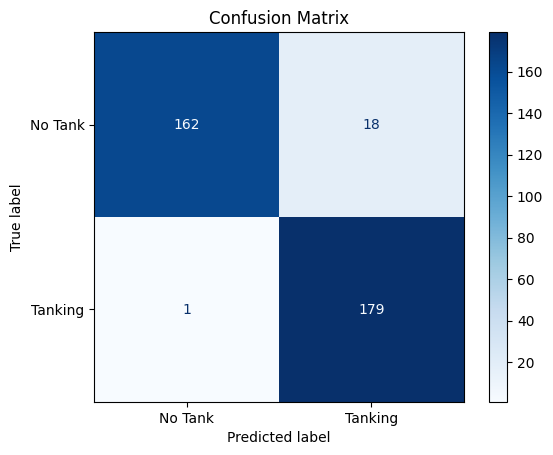

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X_train, y_train = prepare_nn_features_master(df_master)

torch.manual_seed(42)
model = TankingClassifier()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

print("Starting training with augmented data...")
for epoch in range(100):
    model.train()
    predictions = model(X_train)
    loss = criterion(predictions, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        predicted_classes = (predictions > 0.5).float()
        accuracy = (predicted_classes == y_train).float().mean()
        print(f"Epoch {epoch+1:3} | Loss: {loss.item():.4f} | Accuracy: {accuracy:.2%}")

model.eval()

test_team_1 = torch.tensor([[0.1, 0.20, 0.55, 0.2]], dtype=torch.float32)
with torch.no_grad():
    prob = model(test_team_1)
    print(f"\nTanking Probability (Tp) for test_team_1 (high tanking): {prob.item():.2%}")

test_team_2 = torch.tensor([[0.5, 0.75, 0.1, 0.9]], dtype=torch.float32)
with torch.no_grad():
    prob = model(test_team_2)
    print(f"Tanking Probability (Tp) for test_team_2 (low tanking): {prob.item():.2%}")

with torch.no_grad():
   y_pred = (predictions > 0.5).float().cpu().numpy()
   y_true = y_train.cpu().numpy()

cm = confusion_matrix(y_true, y_pred)
labels = ['No Tank', 'Tanking']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix')
plt.show()

### The model should test to have a 95% accuracy after 100 epochs. Tanking probabilities are, therefore, measured very accurately on the 4 variables presented.

## **Monte Carlo Simulation: Adjusting Lottery Odds**

We will now implement the Monte Carlo simulation. The goal is to evaluate the impact of different "tax levels" on the NBA draft lottery. A tax level will penalize teams identified as high-probability tankers, reducing their lottery odds and theoretically disincentivizing tanking. We will compare outcomes across various tax levels to find an optimal solution.

In [ ]:
def get_baseline_lottery_odds(num_teams=14):
    """
    Returns a dictionary of baseline lottery odds for top 4 picks for a given number of teams.
    Odds are for pick 1, 2, 3, 4. (Approximate NBA 2019-present odds for top 4 picks)
    """
    if num_teams == 14:
        odds = [
            [0.140, 0.134, 0.127, 0.120],
            [0.140, 0.134, 0.127, 0.120],
            [0.140, 0.134, 0.127, 0.120],
            [0.125, 0.122, 0.119, 0.115],
            [0.105, 0.105, 0.106, 0.105],
            [0.090, 0.092, 0.094, 0.096],
            [0.075, 0.077, 0.080, 0.083],
            [0.060, 0.063, 0.067, 0.070],
            [0.045, 0.048, 0.052, 0.057],
            [0.030, 0.033, 0.037, 0.042],
            [0.020, 0.022, 0.025, 0.029],
            [0.015, 0.017, 0.019, 0.022],
            [0.010, 0.011, 0.013, 0.015],
            [0.005, 0.006, 0.007, 0.008]
        ]
    else:
        raise ValueError("Only 14-team lottery is supported for this example.")

    return {i: {'picks': odds[i]} for i in range(num_teams)}

baseline_odds = get_baseline_lottery_odds()
print("Baseline Lottery Odds for top 3 teams (first pick):")
for i in range(3):
    print(f"Lottery Seed {i}: {baseline_odds[i]['picks'][0]:.2%}")

Baseline Lottery Odds for top 3 teams (first pick):
Lottery Seed 0: 14.00%
Lottery Seed 1: 14.00%
Lottery Seed 2: 14.00%


In [ ]:
def adjust_lottery_odds(baseline_odds, tanking_probabilities, tax_level, tanking_threshold=0.5):
    """
    Adjusts lottery odds based on tanking probabilities and a tax level.
    tanking_probabilities: dict {lottery_seed: tanking_prob_from_nn}
    tax_level: float (0 to 1), percentage reduction in top pick odds for tanking teams.
    """
    adjusted_odds = {seed: {'picks': list(data['picks'])} for seed, data in baseline_odds.items()}

    tanking_teams_info = []
    total_redistributable_odds = [0.0] * 4

    for seed, prob in tanking_probabilities.items():
        if prob > tanking_threshold:
            tanking_teams_info.append((seed, adjusted_odds[seed]['picks'][0], prob))

            for i in range(4):
                reduction = adjusted_odds[seed]['picks'][i] * tax_level
                adjusted_odds[seed]['picks'][i] -= reduction
                total_redistributable_odds[i] += reduction

    non_tanking_teams_seeds = [seed for seed, prob in tanking_probabilities.items() if prob <= tanking_threshold]
    if not non_tanking_teams_seeds:
        return adjusted_odds

    for i in range(4):
        sum_original_odds_non_tanking = sum(baseline_odds[s]['picks'][i] for s in non_tanking_teams_seeds)

        if sum_original_odds_non_tanking > 0:
            for seed in non_tanking_teams_seeds:
                share = baseline_odds[seed]['picks'][i] / sum_original_odds_non_tanking
                adjusted_odds[seed]['picks'][i] += total_redistributable_odds[i] * share

    for seed in adjusted_odds:
        adjusted_odds[seed]['picks'] = [max(0.0, p) for p in adjusted_odds[seed]['picks']]
        # Note: We're only adjusting top 4 pick odds here. The overall odds might not sum to 100% implicitly.
        # A full implementation would adjust all pick odds and ensure they sum correctly.

    return adjusted_odds

## Prep for Monte Carlo Sim: What is Happening?

This complex tax and redistribute system created above is the algorithm behind our Monte Carlo sims. What basically happens is the following:

- Using the Tp value, a tanker or non-tanker is identified

**Assuming tanker**
- "Steal" the set tax value from their odds by subtracting this value from their original odds and then store that value in a list, called total_redistributable_odds
- The value is then divided by the amount of non-tanking teams in the lottery and then that value is added to each non-tanking team's original odds. This process is done for each pick individually

**Assuming non-tanker**
- Non-tankers only stand to benefit from "stealing" from tanking teams


### **Example**:
Let's say that the Wizards tanked this year (sorry to the three Wizards fans out there) and the Hornets and Nets were simply two bad teams that couldn't get it together. The Wizards, Hornets, and Nets were all projected to have the first pick which means each of their odds are:

- [0.140, 0.134, 0.127, 0.120] for the 1st, 2nd, 3rd, and 4th pick respectively

- Let's set their Tp's to be 0.6, 0.3, and 0.25 for the Wizards, Hornets and Nets repsectively.

- The tax level we will set at 0.35 (this is what the monte carlo is trying to calculate so this will be different for each simulation)



---



Here is what would happen for each team (I'll use first pick, 1RP, as an example):

- The amount being stolen is: 0.14*0.35 = 0.049
- There are two teams stealing this so they each "steal": 0.049/2 = 0.0245

Wizards: Their original 1RP odds decrease from 14% to {0.14 - 0.049} ~ 0.091 or 9.1%

Hornets: Their original 1RP odds increase from 14% to {0.14 + 0.0245) ~ 0.165 or 16.5%

Nets:Their original 1RP odds increase from 14% to {0.14 + 0.0245) ~ 0.165 or 16.5%

## Monte Carlo Simulation

In [ ]:
def run_monte_carlo_simulation(adjusted_odds, num_simulations=10000, num_teams=14):
    """
    Runs Monte Carlo simulations for the NBA draft lottery with sequential draws.
    Once a team wins a pick, they are removed from subsequent draws within the same simulation.
    adjusted_odds: dict {lottery_seed: {'picks': [P1_odds, P2_odds, P3_odds, P4_odds]}}
    num_simulations: int, number of times to simulate the lottery.
    num_teams: int, total number of lottery teams.
    """
    simulation_results = {i: {pick_num: 0 for pick_num in range(4)} for i in range(num_teams)}

    all_adjusted_odds_for_picks = []
    for pick_idx in range(4):
        pick_odds_for_all_teams = np.array([adjusted_odds[i]['picks'][pick_idx] for i in range(num_teams)])
        all_adjusted_odds_for_picks.append(pick_odds_for_all_teams)

    for _ in range(num_simulations):
        teams_already_picked_in_this_simulation = set()

        for pick_num in range(4):
            current_pick_probabilities_all_teams = all_adjusted_odds_for_picks[pick_num].copy()

            for picked_team_id in teams_already_picked_in_this_simulation:
                current_pick_probabilities_all_teams[picked_team_id] = 0.0

            sum_current_probs = np.sum(current_pick_probabilities_all_teams)

            if sum_current_probs > 0:
                normalized_probabilities = current_pick_probabilities_all_teams / sum_current_probs
            else:
                remaining_teams_for_fallback = [
                    t for t in range(num_teams) if t not in teams_already_picked_in_this_simulation
                ]
                if not remaining_teams_for_fallback:
                    break

                normalized_probabilities = np.zeros(num_teams)
                prob_per_team = 1.0 / len(remaining_teams_for_fallback)
                for t in remaining_teams_for_fallback:
                    normalized_probabilities[t] = prob_per_team

            winner_seed = np.random.choice(num_teams, p=normalized_probabilities)

            simulation_results[winner_seed][pick_num] += 1
            teams_already_picked_in_this_simulation.add(winner_seed)

    for seed in simulation_results:
        for pick_num in simulation_results[seed]:
            simulation_results[seed][pick_num] = simulation_results[seed][pick_num] / num_simulations

    return simulation_results

## The Monte Carlo Sim

We create a nested dictionary that intakes both teams and picks; then, we load in our input data and reformat it before simulation. During the simulation, we first handle the edge case of teams not being able to pick twice and handle the probability normalization that would follow. When a team can no longer pick, its "probability of picking" is set to 0, but the cumulative odds of all teams must add to 1, so the remaining odds are standardized to fit that criterion.  Finally, this continues (four times since there we are only measuring for four picks) until a winner is recorded, and this entire process occurs 10,000 times.

In [ ]:
model.eval()
with torch.no_grad():
  full_dataset_probs = model(X_train).squeeze().tolist()

df_master['tanking_prob'] = full_dataset_probs

In [ ]:
tax_level_dict = {'Baseline': 0.0, 'Gentle': 0.25, 'Moderate': 0.5, 'Aggressive': 1.0 }
num_virtual_seasons = 1000
all_simulation_summaries=[]

for i in range(num_virtual_seasons):
  virtual_lottery_pool = df_master.sample(n=14, replace=False)
  seed_maps = {seed: prob for seed, prob in enumerate(virtual_lottery_pool['tanking_prob'])}
  for tax_name, tax_value in tax_level_dict.items():
    current_baseline_odds = get_baseline_lottery_odds(num_teams=14)
    adjusted_odds = adjust_lottery_odds(current_baseline_odds, seed_maps, tax_value)
    results = run_monte_carlo_simulation(adjusted_odds, num_simulations=1000)
    for seed in range(14):
        team_info = virtual_lottery_pool.iloc[seed]
        team_name = team_info['description_label'] if 'description_label' in team_info else f"Team {seed}"
        is_tanker = team_info['is_tanking_label'] if 'is_tanking_label' in team_info else None
        win_prob_p1 = results[seed][0]
        all_simulation_summaries.append({
            'virtual_season': i,
            'tax_level': tax_name,
            'lottery_seed': seed,
            'team': team_name,
            'is_tanker': is_tanker,
            'tp_score': seed_maps[seed],
            'p1_probability': win_prob_p1
        })


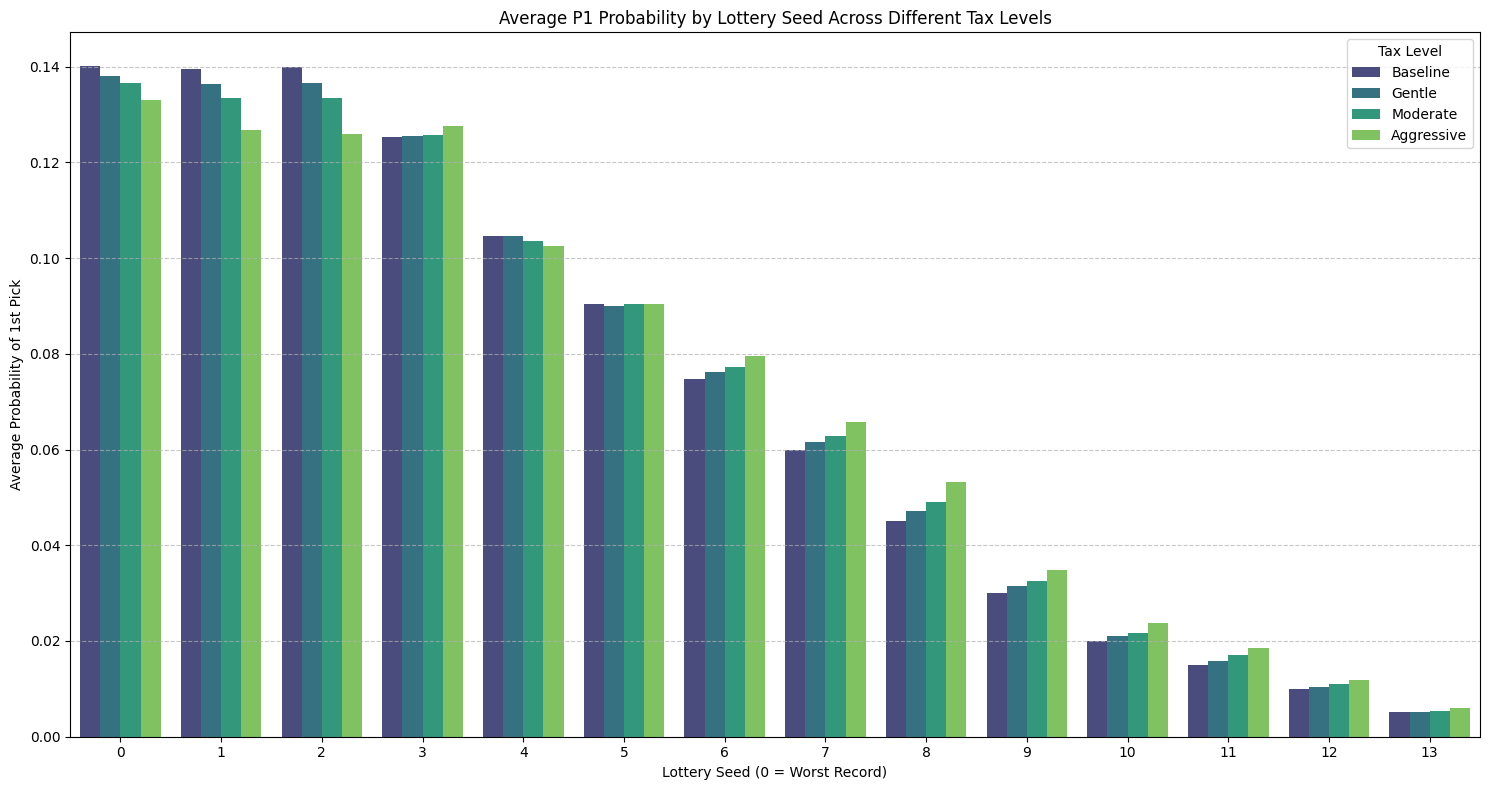

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_summary = pd.DataFrame(all_simulation_summaries)

df_plot = df_summary.groupby(['tax_level', 'lottery_seed'])['p1_probability'].mean().reset_index()

tax_level_order = ['Baseline', 'Gentle', 'Moderate', 'Aggressive']
df_plot['tax_level'] = pd.Categorical(df_plot['tax_level'], categories=tax_level_order, ordered=True)
df_plot = df_plot.sort_values('tax_level')

plt.figure(figsize=(15, 8))
sns.barplot(x='lottery_seed', y='p1_probability', hue='tax_level', data=df_plot, palette='viridis')
plt.title('Average P1 Probability by Lottery Seed Across Different Tax Levels')
plt.xlabel('Lottery Seed (0 = Worst Record)')
plt.ylabel('Average Probability of 1st Pick')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Tax Level')
plt.xticks(np.arange(0, 14, 1))
plt.tight_layout()
plt.show()

## Results and Conclusion
In the graph above, we plotted our monte carlo results, which display some interesting results:

- The distribution flattens as the tax level gets more aggressive. Conceptually, this can be attributed to a general higher probability of tanking associated with the three worst teams in the NBA

- Because of the redistribution process that was implemented, the teams with the 6th lottery seed and beyond actually see an increased probability of getting the first pick as the tax level becomes more aggressive

Two intriguing results that could use further testing are:

- Why is it that the fourth lottery seed, assuming an aggressive tax level, benefits with a higher probability of getting the first pick while the fifth lottery seed actually sees a decrease in probability of getting the first pick?

- The current taxation redistribution process works in a proportional manner, where the team with the highest probability of getting the first pick after all tanking teams are revealed gets more of the share than those who had a lesser chance after tanking teams were revealed. The tanking teams, however, are not removed from the lottery, they are simply taxed. If teams were allowed to be removed from the lottery, effectively forfeiting their pick, how would this change and/or eliminate the dynamic of tanking?